Selecciona los archivos .txt de SpectraSuite


Saving M1p3bourbon2.txt to M1p3bourbon2.txt
  ✓ M1p3bourbon2.txt  →  3047 puntos cargados

 Promedio calculado sobre 1 espectro(s).


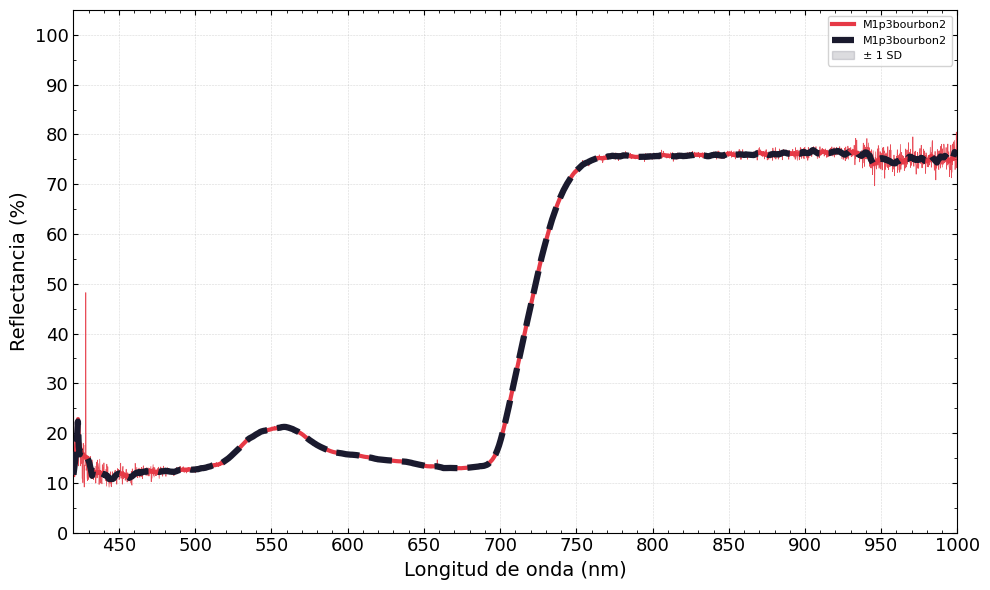

In [6]:
# ============================================================
#  Espectros de  Reflectancia - Promedio y SD
# ============================================================
'''
Este programa solo procesa los .txt de SpectraSuite y los grafica suavizando con Savitzky Golay junto con su promedio de mediciones y desviación estandar
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import savgol_filter
from google.colab import files
import io

# --- Savitzky-Golay ---
SG_WINDOW    = 41
SG_POLYORDER = 2

# --- Rango de ejes ---
X_MIN, X_MAX = 420, 1000    # límites eje X (nm)
Y_MIN, Y_MAX = 0, 105      # límites eje Y (%)

# --- Ticks (marcas de los ejes) ---
X_TICK_MAJOR = 50          # cada cuánto va un número en X  (ej: 400, 500, 600...)
X_TICK_MINOR = 10            # subdivisiones entre cada número en X
Y_TICK_MAJOR = 10           # cada cuánto va un número en Y  (ej: 0, 10, 20...)
Y_TICK_MINOR = 5            # subdivisiones entre cada número en Y

# --- Tamaño de fuente ---
FONTSIZE_LABEL  = 14        # "Longitud de onda (nm)" y "Reflectancia (%)"
FONTSIZE_TITLE  = 14        # título de la figura
FONTSIZE_TICKS  = 13        # números sobre los ejes
FONTSIZE_LEGEND = 8        # texto de la leyenda

# --- Estética ---
LINEWIDTH_RAW    = 0.5
LINEWIDTH_SMOOTH = 3.0
LINEWIDTH_AVG    = 4.5
ALPHA_RAW        = 0.9 # transparencia
ALPHA_INDIVIDUAL = 0.9 # transparencia de las lineas que explica que es cada espectro
FIGSIZE          = (10, 6)  # (ancho, alto) en pulgadas
SHOW_LEGEND      = True

PALETTE = [ # hay 20 colores
    "#E63946",  # rojo
    "#F4A261",  # naranja
    "#2A9D8F",  # verde azulado
    "#457B9D",  # azul acero
    "#9B5DE5",  # violeta
    "#F15BB5",  # rosa
    "#00B4D8",  # cian
    "#FFBE0B",  # amarillo
    "#06D6A0",  # menta
    "#FB5607",  # naranja oscuro
    "#6A0572",  # púrpura oscuro
    "#C9F030",  # lima eléctrico
    "#FF595E",  # sandía
    "#1982C4",  # azul cobalto
    "#8AC926",  # verde manzana
    "#FF924C",  # durazno
    "#4CC9F0",  # celeste hielo
    "#B5179E",  # magenta
    "#3A86FF",  # azul eléctrico
    "#CAFFBF",  # verde pastel
]

COLOR_AVG = "#1A1A2E"   # color de la curva promedio (negro azulado)

# ============================================================
#  FUNCIONES
# ============================================================

def leer_espectrasuite(contenido_bytes):
    texto = contenido_bytes.decode("latin-1")
    lineas = texto.splitlines()
    inicio = None
    for i, linea in enumerate(lineas):
        if "Comienza Data" in linea or "Begin Spectral" in linea or "Data" in linea.title():
            inicio = i + 1
            break
    if inicio is None:
        raise ValueError("No se encontró el marcador de inicio de datos.")
    filas = []
    for linea in lineas[inicio:]:
        linea = linea.strip()
        if not linea:
            continue
        partes = linea.replace(",", ".").split()
        if len(partes) >= 2:
            try:
                filas.append((float(partes[0]), float(partes[1])))
            except ValueError:
                continue
    return pd.DataFrame(filas, columns=["wavelength", "reflectance"])


def suavizar(df, window=SG_WINDOW, polyorder=SG_POLYORDER):
    n = len(df)
    w = window if window % 2 == 1 else window + 1
    w = min(w, n if n % 2 == 1 else n - 1)
    df["smooth"] = savgol_filter(df["reflectance"], window_length=w, polyorder=polyorder)
    return df


# ────────────────────────────────────────────────────
def calcular_promedio(datasets):
    """
    Interpola todos los espectros a una grilla común y devuelve
    un DataFrame con el promedio y la desviación estándar.
    """
    if not datasets:
        return None

    # Grilla común: rango compartido por todos los espectros
    wl_min = max(df["wavelength"].min() for df in datasets.values())
    wl_max = min(df["wavelength"].max() for df in datasets.values())
    grilla = np.linspace(wl_min, wl_max, 1000)

    # Interpolar cada espectro suavizado a la grilla común
    interpolados = []
    for df in datasets.values():
        ref_interp = np.interp(grilla, df["wavelength"], df["smooth"])
        interpolados.append(ref_interp)

    matriz = np.array(interpolados)   # shape: (n_archivos, n_puntos)
    promedio = matriz.mean(axis=0)
    std      = matriz.std(axis=0)

    return pd.DataFrame({
        "wavelength": grilla,
        "mean":       promedio,
        "std":        std,
    })
# ─────────────────────────────────────────────────────────────

#  CARGA DE ARCHIVOS

print("Selecciona los archivos .txt de SpectraSuite")
uploaded = files.upload()

datasets = {}
for nombre, contenido in uploaded.items():
    try:
        df = leer_espectrasuite(contenido)
        df = suavizar(df)
        df = df[(df["wavelength"] >= X_MIN) & (df["wavelength"] <= X_MAX)].reset_index(drop=True)
        datasets[nombre] = df
        print(f"  ✓ {nombre}  →  {len(df)} puntos cargados")
    except Exception as e:
        print(f"  ✗ {nombre}  →  Error: {e}")

# calcular promedio ──────────────────────────────────
df_avg = calcular_promedio(datasets)
if df_avg is not None:
    print(f"\n Promedio calculado sobre {len(datasets)} espectro(s).")
# ─────────────────────────────────────────────────────────────

#  GRÁFICA

fig, ax = plt.subplots(figsize=FIGSIZE)

hay_promedio = df_avg is not None and len(datasets) > 1

for idx, (nombre, df) in enumerate(datasets.items()):
    color = PALETTE[idx % len(PALETTE)]
    etiqueta = nombre.replace(".txt", "").replace(".csv", "").replace("_", " ")

    # Línea cruda
    if LINEWIDTH_RAW > 0:
        ax.plot(df["wavelength"], df["reflectance"],
                color=color, linewidth=LINEWIDTH_RAW, alpha=ALPHA_RAW)

    # Línea suavizada — más tenue si existe promedio
    alpha_s = ALPHA_INDIVIDUAL if hay_promedio else 1.0
    ax.plot(df["wavelength"], df["smooth"],
            color=color, linewidth=LINEWIDTH_SMOOTH,
            alpha=alpha_s, label=etiqueta)
1
# curva promedio + banda de desviación estándar ──────
if df_avg is not None:
    etiqueta_avg = "Promedio" if len(datasets) > 1 else list(datasets.keys())[0].replace(".txt","")
    ax.plot(df_avg["wavelength"], df_avg["mean"],
            color=COLOR_AVG, linewidth=LINEWIDTH_AVG,
            linestyle="--", label=etiqueta_avg, zorder=5)
    ax.fill_between(df_avg["wavelength"],
                    df_avg["mean"] - df_avg["std"],
                    df_avg["mean"] + df_avg["std"],
                    color=COLOR_AVG, alpha=0.15, label="± 1 SD")
# ─────────────────────────────────────────────────────────────

# --- Ejes y etiquetas ---
ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xlabel("Longitud de onda (nm)", fontsize=FONTSIZE_LABEL)
ax.set_ylabel("Reflectancia (%)",      fontsize=FONTSIZE_LABEL)
ax.set_title("", fontsize=FONTSIZE_TITLE, fontweight="bold")

# Ticks mayores (números)
ax.xaxis.set_major_locator(ticker.MultipleLocator(X_TICK_MAJOR))
ax.yaxis.set_major_locator(ticker.MultipleLocator(Y_TICK_MAJOR))

# Ticks menores (subdivisiones)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(X_TICK_MINOR))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(Y_TICK_MINOR))

# Tamaño de los números en los ejes
ax.tick_params(axis="both", which="major", labelsize=FONTSIZE_TICKS,
               direction="in", top=True, right=True)
ax.tick_params(axis="both", which="minor",
               direction="in", top=True, right=True)

ax.grid(True, which="major", linestyle="--", linewidth=0.4, alpha=0.5)

if SHOW_LEGEND:
    ax.legend(framealpha=0.85, fontsize=FONTSIZE_LEGEND)

plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import savgol_filter
from scipy import stats
from scikit_posthocs import posthoc_dunn
from google.colab import files
import warnings
warnings.filterwarnings("ignore")

# ============================================================
#  PARÁMETROS CONFIGURABLES
# ============================================================

# --- Savitzky-Golay ---
SG_WINDOW    = 41
SG_POLYORDER = 2

# --- Rango de ejes ---
X_MIN, X_MAX = 425, 1000
Y_MIN, Y_MAX = 0, 105

# --- Ticks ---
X_TICK_MAJOR = 100
X_TICK_MINOR = 20
Y_TICK_MAJOR = 10
Y_TICK_MINOR = 5

# --- Fuentes ---
FONTSIZE_LABEL  = 13
FONTSIZE_TITLE  = 14
FONTSIZE_TICKS  = 11
FONTSIZE_LEGEND = 10

# --- Estética ---
LINEWIDTH_RAW    = 0.6
LINEWIDTH_SMOOTH = 2.0
LINEWIDTH_AVG    = 2.5
ALPHA_RAW        = 0.3
ALPHA_INDIVIDUAL = 0.5
FIGSIZE          = (12, 6)
SHOW_LEGEND      = True

# Colores por grupo
COLOR_GRUPOS = {
    "S1": "#2A9D8F",   # verde azulado  - sana grupo 1
    "S2": "#457B9D",   # azul acero     - sana grupo 2
    "L1": "#E63946",   # rojo           - lesión grupo 1
    "L2": "#F4A261",   # naranja        - lesión grupo 2
}
COLOR_AVG = {
    "S1": "#1A6B61",
    "S2": "#1D4E6B",
    "L1": "#9B1B24",
    "L2": "#B56A1F",
}

# ============================================================
#  FUNCIONES DE LECTURA Y PROCESAMIENTO
# ============================================================

def leer_espectrasuite(contenido_bytes):
    texto = contenido_bytes.decode("latin-1")
    lineas = texto.splitlines()
    inicio = None
    for i, linea in enumerate(lineas):
        if "Comienza Data" in linea or "Begin Spectral" in linea:
            inicio = i + 1
            break
    if inicio is None:
        raise ValueError("No se encontró el marcador de inicio de datos.")
    filas = []
    for linea in lineas[inicio:]:
        linea = linea.strip()
        if not linea:
            continue
        partes = linea.replace(",", ".").split()
        if len(partes) >= 2:
            try:
                filas.append((float(partes[0]), float(partes[1])))
            except ValueError:
                continue
    return pd.DataFrame(filas, columns=["wavelength", "reflectance"])


def suavizar(df, window=SG_WINDOW, polyorder=SG_POLYORDER):
    n = len(df)
    w = window if window % 2 == 1 else window + 1
    w = min(w, n if n % 2 == 1 else n - 1)
    df["smooth"] = savgol_filter(df["reflectance"], window_length=w, polyorder=polyorder)
    return df


def identificar_grupo(nombre):
    """
    Detecta el grupo a partir del nombre del archivo.
    Retorna: 'S1', 'S2', 'L1' o 'L2'
    """
    n = nombre.lower()
    if "sana" in n or "sano" in n:
        return "S1" if "hoja1" in n else "S2"
    elif "lesion" in n or "lesión" in n:
        return "L1" if "hoja1" in n else "L2"
    return "DESCONOCIDO"


def identificar_punto(nombre):
    """Extrae el número de punto (p1..p6) del nombre."""
    import re
    m = re.search(r'_p(\d+)', nombre.lower())
    return int(m.group(1)) if m else -1


def get_reflectance_at(df, wavelength, tol=5):
    """Devuelve la reflectancia suavizada más cercana a una longitud de onda."""
    idx = (df["wavelength"] - wavelength).abs().idxmin()
    if abs(df.loc[idx, "wavelength"] - wavelength) <= tol:
        return df.loc[idx, "smooth"]
    return np.nan


# ============================================================
#  ÍNDICES ESPECTRALES
# ============================================================

def calcular_indices(df):
    """Calcula NDVI, PRI, PSRI y CARI desde un espectro suavizado."""

    def R(wl): return get_reflectance_at(df, wl)

    # NDVI
    ndvi = (R(800) - R(670)) / (R(800) + R(670))

    # PRI
    pri = (R(531) - R(570)) / (R(531) + R(570))

    # PSRI
    psri = (R(678) - R(500)) / R(750)

    # CARI
    r550, r670, r700 = R(550), R(670), R(700)
    a = (r700 - r550) / 150
    b = r550 - 550 * a
    cari_num = abs(a * r670 + r670 + b)   # nota: debería ser a*670 + R670 + b
    cari_den = np.sqrt(a**2 + 1)
    cari = (r700 / r670) * (cari_num / cari_den) if (r670 != 0 and cari_den != 0) else np.nan

    return {"NDVI": ndvi, "PRI": pri, "PSRI": psri, "CARI": cari}


def calcular_promedio_grupo(datasets_grupo):
    """Interpola y promedia espectros de un grupo."""
    wl_min = max(df["wavelength"].min() for df in datasets_grupo)
    wl_max = min(df["wavelength"].max() for df in datasets_grupo)
    grilla = np.linspace(wl_min, wl_max, 1000)
    interpolados = [np.interp(grilla, df["wavelength"], df["smooth"]) for df in datasets_grupo]
    matriz = np.array(interpolados)
    return pd.DataFrame({
        "wavelength": grilla,
        "mean": matriz.mean(axis=0),
        "std":  matriz.std(axis=0, ddof=1),
    })


# ============================================================
#  CARGA DE ARCHIVOS
# ============================================================

print("📂 Selecciona todos los archivos .txt...")
uploaded = files.upload()

# Estructura: datos[grupo][punto] = [df_medida1, df_medida2, df_medida3]
from collections import defaultdict
datos = defaultdict(lambda: defaultdict(list))
errores = []

for nombre, contenido in uploaded.items():
    try:
        df = leer_espectrasuite(contenido)
        df = suavizar(df)
        df = df[(df["wavelength"] >= X_MIN) & (df["wavelength"] <= X_MAX)].reset_index(drop=True)
        grupo = identificar_grupo(nombre)
        punto = identificar_punto(nombre)
        datos[grupo][punto].append(df)
        print(f"  ✓ {nombre}  →  grupo={grupo}  punto={punto}  ({len(df)} pts)")
    except Exception as e:
        errores.append(nombre)
        print(f"  ✗ {nombre}  →  Error: {e}")

print(f"\n📊 Resumen: {sum(len(p) for g in datos.values() for p in g.values())} mediciones cargadas")
if errores:
    print(f"  ⚠ {len(errores)} archivos con error: {errores}")

# ============================================================
#  CÁLCULO DE ÍNDICES POR PUNTO
# ============================================================

print("\n📐 Calculando índices espectrales...")

# indices_punto[grupo][punto] = {NDVI: val, PRI: val, ...} (promedio de 3 medidas)
indices_punto  = defaultdict(dict)
registros_tabla = []

for grupo, puntos in datos.items():
    for punto, medidas in puntos.items():
        indices_medidas = [calcular_indices(df) for df in medidas]
        # Promedio de las 3 medidas por punto
        for idx_name in ["NDVI", "PRI", "PSRI", "CARI"]:
            vals = [m[idx_name] for m in indices_medidas if not np.isnan(m[idx_name])]
            indices_punto[grupo][punto] = indices_punto[grupo].get(punto, {})
            indices_punto[grupo][punto][idx_name] = np.mean(vals) if vals else np.nan
        registros_tabla.append({
            "Grupo": grupo,
            "Punto": punto,
            **indices_punto[grupo][punto]
        })

df_indices = pd.DataFrame(registros_tabla).sort_values(["Grupo", "Punto"])
print(df_indices.to_string(index=False))

# ============================================================
#  ESTADÍSTICA: SHAPIRO-WILK + ANOVA o KRUSKAL-WALLIS
# ============================================================

print("\n📊 Análisis estadístico...")
grupos_orden = ["S1", "S2", "L1", "L2"]

for idx_name in ["NDVI", "PRI", "PSRI", "CARI"]:
    print(f"\n── {idx_name} ──────────────────────────────")

    muestras = {}
    for g in grupos_orden:
        if g in indices_punto:
            vals = [indices_punto[g][p][idx_name]
                    for p in indices_punto[g]
                    if idx_name in indices_punto[g][p]
                    and not np.isnan(indices_punto[g][p][idx_name])]
            muestras[g] = vals
            m, s = np.mean(vals), np.std(vals, ddof=1)
            print(f"  {g}: n={len(vals)}  media={m:.4f}  SD={s:.4f}")

    # Shapiro-Wilk por grupo
    normal = True
    for g, vals in muestras.items():
        if len(vals) >= 3:
            stat, p = stats.shapiro(vals)
            sig = "✓ normal" if p > 0.05 else "✗ NO normal"
            print(f"  Shapiro-Wilk {g}: W={stat:.3f}  p={p:.4f}  {sig}")
            if p <= 0.05:
                normal = False

    listas = [muestras[g] for g in grupos_orden if g in muestras and len(muestras[g]) > 0]

    if normal:
        # ANOVA de un factor
        stat, p = stats.f_oneway(*listas)
        print(f"  ANOVA: F={stat:.4f}  p={p:.4f}  {'*** SIGNIFICATIVO' if p<0.05 else 'no significativo'}")
        if p < 0.05:
            # Tukey HSD
            from statsmodels.stats.multicomp import pairwise_tukeyhsd
            all_vals   = [v for g in grupos_orden if g in muestras for v in muestras[g]]
            all_labels = [g for g in grupos_orden if g in muestras for v in muestras[g]]
            tukey = pairwise_tukeyhsd(all_vals, all_labels, alpha=0.05)
            print(tukey)
    else:
        # Kruskal-Wallis
        stat, p = stats.kruskal(*listas)
        print(f"  Kruskal-Wallis: H={stat:.4f}  p={p:.4f}  {'*** SIGNIFICATIVO' if p<0.05 else 'no significativo'}")
        if p < 0.05:
            # Dunn post-hoc
            # The `posthoc_dunn` function expects `a` to be a list of lists (groups) if `val_col` and `group_col` are not specified.
            # `listas` already has this format.
            dunn = posthoc_dunn(listas, p_adjust="bonferroni")
            print("  Dunn post-hoc (p-valores):")
            print(dunn)

# ============================================================
#  GRÁFICA DE ESPECTROS
# ============================================================

print("\n📈 Generando gráfica de espectros...")
fig, ax = plt.subplots(figsize=FIGSIZE)

for grupo in grupos_orden:
    if grupo not in datos:
        continue
    color    = COLOR_GRUPOS[grupo]
    color_av = COLOR_AVG[grupo]
    todas_medidas = [df for puntos in datos[grupo].values() for df in puntos]

    # Espectros individuales (tenues)
    for df in todas_medidas:
        if LINEWIDTH_RAW > 0:
            ax.plot(df["wavelength"], df["reflectance"],
                    color=color, linewidth=LINEWIDTH_RAW, alpha=ALPHA_RAW)
        ax.plot(df["wavelength"], df["smooth"],
                color=color, linewidth=LINEWIDTH_SMOOTH, alpha=ALPHA_INDIVIDUAL)

    # Promedio del grupo
    df_avg = calcular_promedio_grupo(todas_medidas)
    etiquetas = {"S1": "Sana G1", "S2": "Sana G2", "L1": "Lesión G1", "L2": "Lesión G2"}
    ax.plot(df_avg["wavelength"], df_avg["mean"],
            color=color_av, linewidth=LINEWIDTH_AVG,
            linestyle="--", label=etiquetas[grupo], zorder=5)
    ax.fill_between(df_avg["wavelength"],
                    df_avg["mean"] - df_avg["std"],
                    df_avg["mean"] + df_avg["std"],
                    color=color_av, alpha=0.12)

ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xlabel("Longitud de onda (nm)", fontsize=FONTSIZE_LABEL)
ax.set_ylabel("Reflectancia (%)",      fontsize=FONTSIZE_LABEL)
ax.set_title("Espectros de Reflectancia por Grupo", fontsize=FONTSIZE_TITLE, fontweight="bold")
ax.xaxis.set_major_locator(ticker.MultipleLocator(X_TICK_MAJOR))
ax.yaxis.set_major_locator(ticker.MultipleLocator(Y_TICK_MAJOR))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(X_TICK_MINOR))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(Y_TICK_MINOR))
ax.tick_params(axis="both", which="major", labelsize=FONTSIZE_TICKS, direction="in", top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", top=True, right=True)
ax.grid(True, which="major", linestyle="--", linewidth=0.4, alpha=0.5)
if SHOW_LEGEND:
    ax.legend(framealpha=0.85, fontsize=FONTSIZE_LEGEND)

plt.tight_layout()
plt.savefig("espectros_grupos.png", dpi=200, bbox_inches="tight")
plt.show()

# ============================================================
#  GRÁFICA DE ÍNDICES (boxplot por grupo)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
indices_lista = ["NDVI", "PRI", "PSRI", "CARI"]

for ax, idx_name in zip(axes, indices_lista):
    data_box  = [muestras.get(g, []) for g in grupos_orden]
    colores   = [COLOR_GRUPOS.get(g, "#999") for g in grupos_orden]
    bp = ax.boxplot(data_box, patch_artist=True, widths=0.5,
                    medianprops=dict(color="white", linewidth=2))
    for patch, color in zip(bp["boxes"], colores):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticks(range(1, len(grupos_orden)+1))
    ax.set_xticklabels(["Sana G1", "Sana G2", "Lesión G1", "Lesión G2"], fontsize=10)
    ax.set_title(idx_name, fontsize=13, fontweight="bold")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
    ax.tick_params(which="both", direction="in")

plt.suptitle("Índices Espectrales por Grupo", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("indices_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()

# ============================================================
#  EXPORTAR RESULTADOS
# ============================================================

df_indices.to_csv("indices_espectrales.csv", index=False, float_format="%.5f")
print("\n Archivos guardados:")
print("   espectros_grupos.png")
print("   indices_boxplot.png")
print("   indices_espectrales.csv")

📂 Selecciona todos los archivos .txt...


Saving M1p1bourbon3.txt to M1p1bourbon3.txt
  ✓ M1p1bourbon3.txt  →  grupo=DESCONOCIDO  punto=-1  (3024 pts)

📊 Resumen: 1 mediciones cargadas

📐 Calculando índices espectrales...
      Grupo  Punto     NDVI       PRI     PSRI      CARI
DESCONOCIDO     -1 0.758785 -0.072287 0.012283 47.555597

📊 Análisis estadístico...

── NDVI ──────────────────────────────


TypeError: At least two samples are required; got 0.

In [8]:
!pip install scikit-posthocs statsmodels